# eigh/svd nightly benchmark: n=32 cliff gone?

Old cuSOLVER dispatches batched eigh/svd to a fast Jacobi kernel for n≤32, but falls back to a ~165x slower path for n>33. Nightly torch (2.12.0.dev) has optimized the n>32 eigh path. This notebook benchmarks and compares.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from vmc_torch.GPU.torch_utils import svd_via_eigh, qr_via_eigh

print(f"torch {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

device = "cuda"
B = 64
N_WARMUP = 5
N_ITERS = 10

# Dense sampling around the n=32 threshold
n_list = list(range(28, 35, 1))

torch 2.12.0.dev20260310+cu126
GPU: NVIDIA GeForce RTX 4080


## Run benchmark

In [2]:
def time_op(fn, a):
    """Time via CUDA events. Returns ms."""
    for _ in range(N_WARMUP):
        fn(a)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(N_ITERS):
        fn(a)
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / N_ITERS


eigh_times = []
svd_times = []
qr_times = []
svd_eigh_times = []
qr_eigh_times = []

w = 10
print(f"  {'n':>4} | {'eigh':>{w}} | {'svd':>{w}} | {'qr':>{w}} | {'svd_eigh':>{w}} | {'qr_eigh':>{w}}")
print("  " + "-" * (5 * w + 17))

for n in n_list:
    x = torch.randn(B, n, n, device=device, dtype=torch.float64)
    a_sym = (x + x.transpose(-1, -2)) / 2.0
    a_gen = torch.randn(B, n, n, device=device, dtype=torch.float64)

    t_eigh = time_op(torch.linalg.eigh, a_sym)
    t_svd = time_op(torch.linalg.svd, a_gen)
    t_qr = time_op(torch.linalg.qr, a_gen)
    t_svd_eigh = time_op(lambda a: svd_via_eigh(a, jitter=1e-8), a_gen)
    t_qr_eigh = time_op(lambda a: qr_via_eigh(a, jitter=1e-8), a_gen)

    eigh_times.append(t_eigh)
    svd_times.append(t_svd)
    qr_times.append(t_qr)
    svd_eigh_times.append(t_svd_eigh)
    qr_eigh_times.append(t_qr_eigh)

    marker = "  <-- n=32" if n == 32 else ""
    print(
        f"  {n:4d} | {t_eigh:{w}.3f} | {t_svd:{w}.3f} | "
        f"{t_qr:{w}.3f} | {t_svd_eigh:{w}.3f} | {t_qr_eigh:{w}.3f}{marker}"
    )

nightly_data = {
    "n_list": n_list, "B": B,
    "eigh_ms": eigh_times,
    "svd_ms": svd_times,
    "qr_ms": qr_times,
    "svd_eigh_ms": svd_eigh_times,
    "qr_eigh_ms": qr_eigh_times,
    "torch_version": torch.__version__,
    "gpu_name": torch.cuda.get_device_name(0),
}
np.save("eigh_nightly_timing.npy", nightly_data)
print(f"\nSaved to eigh_nightly_timing.npy")

     n |       eigh |        svd |         qr |   svd_eigh |    qr_eigh
  -------------------------------------------------------------------
    28 |      1.011 |      6.781 |      5.463 |      2.600 |      1.868
    29 |      2.410 |      4.104 |      4.879 |      1.417 |      1.676
    30 |      1.027 |      4.138 |      5.407 |      1.474 |      1.560
    31 |      1.102 |      4.355 |      6.089 |      1.808 |      1.672
    32 |      1.077 |      5.985 |     10.571 |      2.594 |      2.106  <-- n=32
    33 |      5.908 |    612.951 |     16.308 |      4.330 |      5.173
    34 |      3.376 |    766.137 |      8.760 |      3.961 |      4.190

Saved to eigh_nightly_timing.npy


## Plot: wall time for eigh, svd, qr

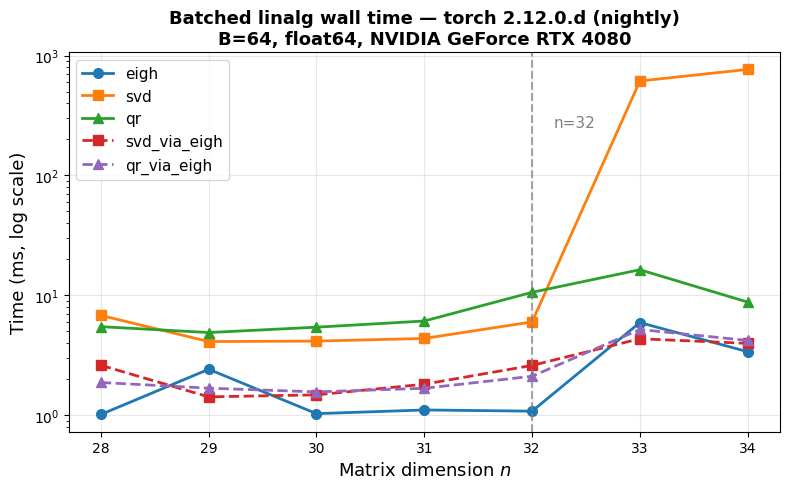

Saved eigh_nightly_walltime.{pdf,png}


In [3]:
new = np.load("eigh_nightly_timing.npy", allow_pickle=True).item()
n_arr = np.array(new["n_list"])

fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(n_arr, new["eigh_ms"], "o-", ms=7, lw=2, label="eigh")
ax.semilogy(n_arr, new["svd_ms"], "s-", ms=7, lw=2, label="svd")
ax.semilogy(n_arr, new["qr_ms"], "^-", ms=7, lw=2, label="qr")
ax.semilogy(n_arr, new["svd_eigh_ms"], "s--", ms=7, lw=2, label="svd_via_eigh")
ax.semilogy(n_arr, new["qr_eigh_ms"], "^--", ms=7, lw=2, label="qr_via_eigh")

ax.axvline(x=32, color="gray", ls="--", alpha=0.7, lw=1.5)
ax.text(32.2, ax.get_ylim()[1] * 0.3, "n=32", color="gray", fontsize=11, va="top")

ax.set_xlabel("Matrix dimension $n$", fontsize=13)
ax.set_ylabel("Time (ms, log scale)", fontsize=13)
ax.set_title(
    f"Batched linalg wall time — torch {new['torch_version'][:8]} (nightly)\n"
    f"B={new['B']}, float64, {new.get('gpu_name', 'GPU')}",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

fig.tight_layout()
# plt.savefig("eigh_nightly_walltime.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("eigh_nightly_walltime.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved eigh_nightly_walltime.{pdf,png}")